<h1 align="center">SWDB Problem Set: Becoming a Data Detective</h1>
<h3 align="center">From someone else's figure to your own analysis</h3>
<p align="center"><b>SOLUTIONS</b> &mdash; worked on the Learning mFISH dataset</p>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2>How this problem set works</h2>

This morning you explored a dataset and made figures. Those figures are now posted on Slack.

**Your starting point is one of your classmates' figures.** Pick any figure from the channel, along
with the dataset it came from &mdash; ideally one you did *not* work on this morning.

| Part | Task |
| --- | --- |
| 1 | Load their dataset and find the pieces the figure needs |
| 2 | Reproduce the figure, and interrogate what it shows |
| 3 | Align activity to event onsets: raster and PSTH |
| 4 | Signal and noise correlations, and whether to trust them |

You already have the data-access skills for Part 1 from this morning's tutorial. This problem set is
about what comes after loading: **shaping data, and checking whether the result means anything.**

**Deliverable:** a short README naming the figure and dataset you chose, the decisions you made at
each step, and an honest assessment of what your numbers do and do not support.

<b>Every dataset is different, and the notebook does not know which one you picked.</b> The code
cells are prompts, not templates &mdash; you write what goes in them, using the access patterns from
this morning. Only a few things are given: the imports, and two helper functions from the tutorial.

The differences you will run into are not cosmetic. Across the datasets in this workshop:

- **Recording modality** &mdash; a continuous calcium signal in some, discrete spike times in
  others. Spikes need binning before anything here applies.
- **Sampling rate** &mdash; from a few Hz to tens of kHz, which sets what timing you can resolve.
- **Number of neurons** &mdash; tens to thousands, which changes what is tractable in one pass.
- **Stimulus structure** &mdash; many conditions with few repeats, few conditions with many, or no
  sensory stimulus at all.
- **What was recorded alongside** &mdash; running, licking, pupil, reward; some datasets have all of
  it, some none.
- **Where things live in the file** &mdash; container and column names differ, and so does which
  container holds the trial table.

None of that is written on the outside of the file. **You have to look.** Part of each prompt is
deciding whether the analysis it asks for even applies to your dataset &mdash; and saying so when it
does not.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2>Taking it slow: Analysis step by step</h2>

You can now generate an analysis faster than you can check one. Ask an LLM for a correlation matrix
and you will have one in thirty seconds, beautifully formatted, with a colorbar.

The problem is that a result computed on four trials can look exactly like a result computed on four
hundred. A bug can look exactly like a finding. A correlation computed in a window where nothing
happened can look exactly like a real effect.

So the questions to keep asking are:

- **What is actually in this file?** Not what you assume &mdash; what is there.
- **Does this dataset support the question I am asking?**
- **How is the data being transformed?** Plot the data after each step.
- **What would make this result wrong?** Name it before you see the answer.

</div>

---

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h1>Part 1: Load the dataset and find the pieces you need</h1>

Same access pattern as this morning: metadata CSV, then navigate to a session's NWB file, then dot
and bracket notation into the containers.

**Your classmate's figure tells you what to look for.** Before you open anything, list the pieces the
figure needs &mdash; neural activity, plus whatever else it plots: a behavioral trace, epoch
boundaries, trial times, stimulus identity.

Then find each one, and note the ones that turn out not to exist. **A piece being absent is a
finding about the dataset, not a failure.** Some datasets have no running wheel, no pupil camera, no
visual stimulus at all. You will build the figure from what is there.

</div>

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pynwb
from scipy import stats

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 30)

data_dir = '/data'

In [2]:
# EDIT: your project's metadata file
metadata = pd.read_csv(os.path.join(data_dir, 'metadata', 'ophys_mFISH_metadata.csv'))
metadata.head()

,subject_id,session_date,session_type,genotype,modality
0,790322,2025-07-02,OPHYS_1_images_A,Slc32a1-IRES-Cre/wt;Oi1(TIT2L-jGCaMP8s-WPRE-ICL-IRES-tTA2)/wt,multiplane-ophys


<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Find a session to work with. Which subject and session type does your
classmate's figure come from?

</div>

In [3]:
# EDIT: navigate to one session, as in the tutorial
subject_id = metadata.subject_id.unique()[0]
session_dir = os.path.join(data_dir, f'{subject_id}_ophys_mFISH')
sessions = sorted(os.listdir(session_dir))
session = sessions[0]

nwb_file = [f for f in os.listdir(os.path.join(session_dir, session))
            if f.endswith('.nwb.zarr')][0]
nwb_path = os.path.join(session_dir, session, nwb_file)
nwb_path

'data/pophys.nwb.zarr'

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<b>A note specific to this example dataset.</b> The ophys-mFISH files are mid-conversion, so
neural and behavior data are still in <b>two separate NWB files</b> that share a session name and a
clock. Most SWDB datasets are a single file with everything in it, and this one will be too once the
conversion finishes.

That is why the cell below opens two files, and why the behavior file is read from its Zarr store
directly &mdash; it declares a custom NWB extension that is not yet installable, so
`pynwb.read_nwb` cannot construct it. **Nothing about this pattern generalizes; skim it and move
on.**

</div>

In [4]:
nwb = pynwb.read_nwb(nwb_path)
nwb

root abc.NdxEventsNWBFile at 0x5713180368
Fields:
  devices: {
    MESO.2 <class 'pynwb.device.Device'>
  }
  experimenter: ["['14394', 'NSB-3543', 'Marina Garrett', 'Peter Groblewski']"]
  file_create_date: [datetime.datetime(2026, 7, 10, 17, 1, 49, 143580, tzinfo=tzutc())]
  identifier: fa1929a0-f111-4140-8ee6-0d3ea8f81d0a
  imaging_planes: {
    VISp_0 <class 'pynwb.ophys.ImagingPlane'>,
    VISp_1 <class 'pynwb.ophys.ImagingPlane'>,
    VISp_2 <class 'pynwb.ophys.ImagingPlane'>,
    VISp_3 <class 'pynwb.ophys.ImagingPlane'>,
    VISp_4 <class 'pynwb.ophys.ImagingPlane'>,
    VISp_5 <class 'pynwb.ophys.ImagingPlane'>,
    VISp_6 <class 'pynwb.ophys.ImagingPlane'>,
    VISp_7 <class 'pynwb.ophys.ImagingPlane'>
  }
  institution: Allen Institute for Neural Dynamics
  lab_meta_data: {
    VISp_0 <class 'pynwb.file.LabMetaData'>,
    VISp_1 <class 'pynwb.file.LabMetaData'>,
    VISp_2 <class 'pynwb.file.LabMetaData'>,
    VISp_3 <class 'pynwb.file.LabMetaData'>,
    VISp_4 <class 'pynwb

In [5]:
# --- TEMPORARY: two-file loading, remove when the merged NWB files land ---
import zarr

def zarr_table(group):
    """Read an NWB table from a Zarr store as a DataFrame."""
    columns = {}
    for key in group.array_keys():
        if key.endswith('_index') or group[key].ndim != 1:
            continue
        values = group[key][:]
        if values.dtype.kind in 'OS':
            values = np.array([v.decode() if isinstance(v, bytes) else v for v in values])
        columns[key] = values
    n = max(len(v) for v in columns.values())
    return pd.DataFrame({k: v for k, v in columns.items() if len(v) == n})


behavior = zarr.open(nwb_path.replace('pophys', 'behavior'), mode='r')
# --- end temporary block ---

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Find the data the figure needs</h3>

Four containers hold almost everything. Which one holds what **varies by dataset**, so list all four
before you index into any of them.

| container | commonly holds |
| --- | --- |
| `processing` | processed neural activity, and often behavior |
| `intervals` | epoch tables, trial tables, stimulus presentation tables |
| `stimulus` | stimulus templates &mdash; but in some datasets, the trial tables too |
| `acquisition` | raw acquired signals |

The last row is not hypothetical: some datasets put their trial tables in `stimulus` and leave
`intervals` holding only epochs. If you look in one container, find nothing, and conclude the data
is missing, you will be wrong. **Print all four.**

</div>

In [6]:
# What is in each file?
print('OPHYS file  -> processing:', list(nwb.processing.keys()))
print('OPHYS file  -> intervals: ', list(nwb.intervals.keys()) if nwb.intervals else [])
print('BEHAVIOR    -> intervals: ', list(behavior['intervals'].group_keys()))

OPHYS file  -> processing: ['VISp_0', 'VISp_1', 'VISp_2', 'VISp_3', 'VISp_4', 'VISp_5', 'VISp_6', 'VISp_7']
OPHYS file  -> intervals:  []
BEHAVIOR    -> intervals:  ['intervals', 'natural_movie_one_presentations', 'stimulus_presentations', 'trials']


<div style="border-left: 3px solid #7B9E3F; padding: 1px; padding-left: 10px; background: #FBFDF7; ">

<b>SOLUTION.</b> <i>Worked here on one example dataset. Your dataset will give different numbers &mdash; the reasoning is what transfers.</i>

The ophys file has 8 imaging planes in `processing` and an **empty** `intervals`
container; the stimulus and trial tables are in the behavior file.

If you had opened only the ophys file, seen `intervals: []`, and concluded the session had no
stimulus information, you would have been wrong. For a normal single-file dataset both appear in the
same listing &mdash; but the general habit is the point: **an empty container means "not here", not
"does not exist".** Check every container, and every file, before concluding something is missing.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<b>Is your dataset continuous or spiking?</b> This is the first fork in the road, and it
changes what "activity" even means.

<b>Continuous</b> (calcium imaging, LFP): a `(n_timepoints, n_cells)` array already exists in the
file. Find it and you are done.

<b>Spiking</b> (Neuropixels, sorted electrophysiology): there is no such array. Each unit carries its
own list of spike times, usually in a `units` table, and you must <b>bin</b> them yourself &mdash;
choose a bin width, count spikes per bin, divide by the width to get a rate in spikes/s. Everything
downstream then works the same way.

Two decisions come with spiking data, and neither has a default:

- <b>Which units.</b> Spike sorting produces more units than you should analyze. There will be
  quality-control columns (`is_qc_pass`, `firing_rate`, `presence_ratio`, `snr`) and often an
  anatomical label. Select on them explicitly and say what you selected &mdash; a session can drop
  from thousands of units to dozens, and the ones you drop change your answer.
- <b>Bin width.</b> Too wide blurs the response; too narrow leaves mostly-empty bins and noisy
  single-trial estimates. Try a few and see how much your answer moves.

<pre>
bin_width = 0.010                                    # seconds -- your decision
edges = np.arange(0, t_end + bin_width, bin_width)
counts, _ = np.histogram(one_unit_spike_times, bins=edges)
rate = counts / bin_width                            # spikes/s
bin_centres = edges[:-1] + bin_width / 2
</pre>

Sparse binned spikes behave like a deconvolved calcium trace: sharper in time, and noisy per
trial.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<b>Two things to check as you pull out the activity trace.</b>

<b>Timestamps.</b> Some datasets store an explicit `timestamps` array; others store a sampling
`rate` and a `starting_time`, and you reconstruct the times yourself. Everything downstream needs
real times in seconds, so check which you have &mdash; `series.timestamps` is `None` when the file
uses a rate.

<b>Lazy loading.</b> NWB data objects do not load until you index them. That is what lets you open a
50&nbsp;GB file instantly, but it means `data.std()` may fail where `np.std(data)` works. Convert
with `np.asarray()` once you know the array is small enough to hold, or slice first.

</div>

In [7]:
# Neural activity: dF/F for one plane
plane = 'VISp_0'
dff_series = nwb.processing[plane]['dff_timeseries']['dff_timeseries']

dff = dff_series.data[:]

# EDIT: some datasets store a rate instead of a timestamps array
if dff_series.timestamps is not None:
    ts = dff_series.timestamps[:]
else:
    ts = np.arange(dff.shape[0]) / dff_series.rate + dff_series.starting_time
    print(f'no timestamps array; reconstructed from rate = {dff_series.rate:.2f} Hz')

print('dff shape (nframes, nrois):', np.shape(dff))
print('timestamps shape:', np.shape(ts))
print(f'frame rate: {1 / np.median(np.diff(ts)):.2f} Hz')
print(f'session duration: {ts[-1] / 60:.1f} min')

dff shape (nframes, nrois): (48366, 51)
timestamps shape: (48366,)
frame rate: 10.74 Hz
session duration: 75.3 min


In [8]:
# Behavior and stimulus tables
running_speed = behavior['processing/running/speed/data'][:]
running_ts = behavior['processing/running/speed/timestamps'][:]

stimulus_table = zarr_table(behavior['intervals/stimulus_presentations'])
trials = zarr_table(behavior['intervals/trials'])

print('running_speed:', running_speed.shape, '| running_ts:', running_ts.shape)
print('stimulus_table:', stimulus_table.shape)
print('trials:', trials.shape)

running_speed: (269914,) | running_ts: (269914,)
stimulus_table: (4798, 14)
trials: (804, 28)


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<b>Plotting a long recording.</b> A whole session at a fine sampling rate can be hundreds of
thousands of points &mdash; slow to draw and impossible to read. Plot a slice instead, but choose the
slice from the data rather than picking a round number: an arbitrary window can easily contain no
activity at all, and an empty panel looks identical to a broken one.

</div>

51 cells, 51 with any data
plotting ROI 3 (SNR 4.79, median 3.89)


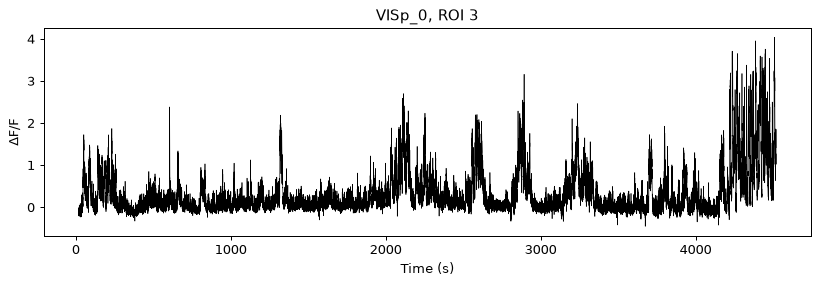

In [9]:
# Sanity check: plot one ROI's trace against time.
# EDIT: try several -- cells differ enormously, and index 0 is not special.
# Here we take a high-SNR cell so the plot shows what real activity looks like.
# NWB data objects are lazy -- np.asarray() pulls them into memory.
# For a very large recording, load a subset of cells or a time slice instead.
dff = np.asarray(dff)

# Some cells can be entirely NaN (failed segmentation, dropped ROIs). Check
# before you index -- a NaN cell will silently poison anything it touches.
usable = np.flatnonzero(~np.isnan(dff).all(axis=0))
print(f'{dff.shape[1]} cells, {len(usable)} with any data')

snr = np.percentile(dff[:, usable], 99, axis=0) / np.std(dff[:, usable], axis=0)
example_roi = int(usable[np.argmax(snr)])

print(f'plotting ROI {example_roi} (SNR {snr.max():.2f}, median {np.median(snr):.2f})')

plt.figure(figsize=(11, 3))
plt.plot(ts, dff[:, example_roi], 'k', lw=0.5)
plt.xlabel('Time (s)')
plt.ylabel(r'$\Delta$F/F')
plt.title(f'{plane}, ROI {example_roi}')
plt.show()

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Look at that trace for a few seconds before moving on. Is anything about it
surprising? Would you have noticed if you had skipped straight to the analysis?

</div>

<div style="border-left: 3px solid #7B9E3F; padding: 1px; padding-left: 10px; background: #FBFDF7; ">

<b>SOLUTION.</b> <i>Worked here on one example dataset. Your dataset will give different numbers &mdash; the reasoning is what transfers.</i>

Two things are visible in our example cell, and only one of them is what you came for.

**The transients.** Sharp upward events on a flat baseline &mdash; this is what calcium activity
should look like, and it tells you the trace is a real signal rather than noise or an artifact.

**The slow envelope.** The activity is not stationary. In this cell the first quarter of the session
averages several times higher than the last quarter, with the largest transients in the middle. Other
cells in the same plane drift the *opposite* way, some by a factor of ten.

Slow changes like this can be biology (arousal, engagement, sensitization) or the recording (z-drift
changing which part of the cell is in focus). The trace alone cannot distinguish them, and this
notebook will not resolve it.

What matters is that you **saw it**, because it has consequences later: anything you compare between
the start and the end of the session is confounded with this trend, and any "response" measured
without subtracting a local baseline partly reflects where the cell's baseline happened to be.

Try a few different ROIs before moving on. Cells differ enormously, and picking index 0 tells you
about index 0. Write what you find in your README &mdash; one plot, thirty seconds, and you know
something no summary statistic would have told you.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>The variables the rest of the notebook uses</h3>

**This is the only cell you edit to run this notebook on a different dataset.** Point these names at
the equivalent pieces of your NWB file; nothing after this cell refers to a dataset by name.

</div>

In [10]:
# =====================================================================
# FILL IN FOR YOUR DATASET
# =====================================================================
activity = dff                    # (n_timepoints, n_cells)
timestamps = ts                   # (n_timepoints,) seconds
events = stimulus_table           # one row per stimulus presentation

CONDITION_COLUMN = 'image_name'   # column that labels the stimulus condition
ONSET_COLUMN = 'start_time'       # column that gives the event time
# =====================================================================

print('activity:', activity.shape, '| events:', events.shape)
print('conditions:', events[CONDITION_COLUMN].nunique())

activity: (48366, 51) | events: (4798, 14)
conditions: 9


<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Print the columns of your stimulus table. Which describe *what was
presented*, which describe *what the animal did*, and which are bookkeeping?

Note any column whose meaning you cannot guess &mdash; that is a databook lookup for your README.

</div>

In [11]:
print(list(events.columns))
events.head()

['HED', 'epoch_name', 'id', 'image_name', 'is_change', 'lick_latency', 'omitted', 'orientation', 'start_frame', 'start_time', 'stimulus_presentations_id', 'stop_frame', 'stop_time', 'trials_id']


,HED,epoch_name,id,image_name,is_change,lick_latency,omitted,orientation,start_frame,start_time,stimulus_presentations_id,stop_frame,stop_time,trials_id
0,"Sensory-event, Visual-presentation, (Image, Label/im065)",change_detection,0,im065,False,NaN,False,NaN,17985,317.777733,0,18000,318.027943,0
1,"Sensory-event, Visual-presentation, (Image, Label/im065)",change_detection,1,im065,False,0.062247,False,NaN,18030,318.528353,1,18045,318.778563,0
2,"Sensory-event, Visual-presentation, (Image, Label/im065)",change_detection,2,im065,False,NaN,False,NaN,18075,319.278983,2,18090,319.529183,1
3,"Sensory-event, Visual-presentation, (Image, Label/im065)",change_detection,3,im065,False,NaN,False,NaN,18120,320.029603,3,18135,320.279833,1
4,"Sensory-event, Visual-presentation, (Image, Label/im065)",change_detection,4,im065,False,NaN,False,NaN,18165,320.780233,4,18180,321.030433,1


<div style="border-left: 3px solid #7B9E3F; padding: 1px; padding-left: 10px; background: #FBFDF7; ">

<b>SOLUTION.</b> <i>Worked here on one example dataset. Your dataset will give different numbers &mdash; the reasoning is what transfers.</i>

In our example, `image_name` and `orientation` describe the stimulus; `is_change` and
`omitted` describe its role in the task; `lick_latency` is behavior; `trials_id` links to the trials
table; `HED` is a semantic annotation string.

`is_change` is the one that matters later. Most presentations repeat the previous image; a few are
changes the animal must report. Those are **not the same kind of event**, and treating them as
interchangeable would mix task-driven licking and reward into a stimulus analysis.

</div>

---

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h1>Part 2: Reproduce the figure, and interrogate what it shows</h1>

You have your classmate's figure. You do not have their code, and you may not have a caption either.

<b>Before you write anything, write down what you think the figure shows.</b> One or two sentences,
in your notebook, as a claim someone could disagree with: <i>"activity is higher during X than during
Y"</i>, <i>"the response is larger on this trial type"</i>, <i>"these two signals rise together."</i>

Two reasons this comes first. It commits you to an interpretation before the data can talk you into
one &mdash; and it converts a picture into something you can actually test. A figure cannot be right
or wrong. A claim can.

</div>

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Write your claim about the figure you picked, in the cell below, before you
write any code.

Be specific enough to be wrong. "There is neural activity" is not a claim; "population activity is
higher in the second half of the session" is.

</div>

_Your claim:_

<!-- write it here -->


<div style="border-left: 3px solid #7B9E3F; padding: 1px; padding-left: 10px; background: #FBFDF7; ">

<b>SOLUTION.</b> <i>Worked here on one example dataset. Your dataset will give different numbers &mdash; the reasoning is what transfers.</i>

For the example figure &mdash; running speed and population activity across the session, with
epochs shaded &mdash; a reasonable claim is:

> *"Population activity is higher during the task block than during the gray-screen periods, and the
> mouse runs in bouts throughout."*

Note what makes this testable: it names two things to compare and asserts a direction. It is also
two claims, not one, and they may not both survive.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<b>Is your timeseries actually continuous?</b>

Most of the time it is. Many datasets record straight through, and this check takes one line and
returns nothing interesting. Do it anyway, because when it <i>does</i> find something the default
plot will not tell you.

Some acquisition systems write behavioral streams per block rather than continuously, so an
experimenter break, a rig adjustment or a script restart can leave an interval with no samples at
all &mdash; the timestamps just jump. Whether that happened is a property of how your session was
run, not something you can infer from the plot.

And the plot will not warn you: <code>plot()</code> draws a straight line between consecutive samples
regardless of how far apart in time they are, so a ten-minute hole becomes a flat segment that looks
exactly like an animal sitting still. <b>Missing data and zero are not the same thing, and the
default plot renders them identically.</b>

So: check the interval between samples once, before you trust any flat stretch. If there are no
gaps &mdash; the common case &mdash; you have spent one cell and can plot normally. If there are, use
the helper below to break the line at them instead of interpolating across.

</div>

In [12]:
def break_gaps(t, y, factor=10):
    """Insert NaN wherever sampling pauses, so plots don't interpolate across it.

    A gap is any interval more than `factor` times the typical one.
    """
    dt = np.diff(t)
    typical = np.median(dt)
    breaks = np.flatnonzero(dt > factor * typical)
    if len(breaks) == 0:
        return t, y
    return (np.insert(np.asarray(t, float), breaks + 1, np.nan),
            np.insert(np.asarray(y, float), breaks + 1, np.nan))

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** For each timeseries in your figure, report the typical sampling interval and
whether any interval is much larger than it.

**Finding none is the likely outcome and a perfectly good answer** &mdash; write down that you
checked and the trace is continuous. If you do find gaps, note how much of the session they cover and
which streams are affected; they may not be the same for every signal.

</div>

In [13]:
# EDIT: list the timeseries your figure uses
streams = [('activity', timestamps)]
if 'running_ts' in dir():
    streams.append(('running', running_ts))

for name, t in streams:
    dt = np.diff(t)
    typical = np.median(dt)
    gaps = dt[dt > 10 * typical]
    print(f'{name}: typical interval {typical*1000:.1f} ms | '
          f'{len(gaps)} gaps | {gaps.sum():.0f} s with no data '
          f'({100*gaps.sum()/t[-1]:.1f}% of session)')
    if len(gaps):
        print('   largest gaps (s):', np.round(np.sort(gaps)[::-1][:5], 1))

activity: typical interval 93.1 ms | 0 gaps | 0 s with no data (0.0% of session)
running: typical interval 16.7 ms | 0 gaps | 0 s with no data (0.0% of session)


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Now rebuild it</h3>

Get the pieces the figure needs and plot them. You will not match it exactly &mdash; different
smoothing, different colors, a different subset of cells &mdash; and that is fine. What matters is
that the structure you see is the same structure they saw.

If you cannot rebuild some element because the dataset does not contain it, note that and rebuild
what you can.

</div>

In [14]:
# The figure needs a population average: mean across cells at each timepoint
population = activity.mean(axis=1)

print('activity:  ', activity.shape, '(timepoints, cells)')
print('population:', population.shape, '(timepoints,)')

activity:   (48366, 51) (timepoints, cells)
population: (48366,) (timepoints,)


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

To shade the epochs we need their start and stop times. Where epochs live varies by dataset:
sometimes an `epoch_name` column on the stimulus table, sometimes a separate epochs table.

**Check that the column you group by actually varies.** If it takes one value, you will get a single
block spanning the session &mdash; a figure that looks fine and is wrong.

</div>

In [15]:
# EDIT: does your stimulus table carry an epoch column, and does it vary?
for column in ['epoch_name', 'stim_name', 'stimulus_block_name', 'stimulus_name']:
    if column in events.columns:
        print(f'{column}: {events[column].nunique()} distinct value(s)')
        print(events[column].value_counts().to_string())
        print()

epoch_name: 1 distinct value(s)
epoch_name
change_detection    4798



<div style="border-left: 3px solid #7B9E3F; padding: 1px; padding-left: 10px; background: #FBFDF7; ">

<b>SOLUTION.</b> <i>Worked here on one example dataset. Your dataset will give different numbers &mdash; the reasoning is what transfers.</i>

In our example the stimulus table carries an epoch column that takes exactly **one**
value, so grouping by it would produce a single block spanning the session &mdash; a figure that
looks fine and is wrong. The real boundaries live in a separate intervals table.

Other datasets go the other way: the stimulus table's epoch column varies properly and is all you
need. Either is fine; the check is what matters. **A column existing does not mean it carries the
information you want.**

</div>

In [16]:
# EDIT: where the epochs live in your dataset
intervals_table = zarr_table(behavior['intervals/intervals'])
epochs = intervals_table[intervals_table.interval_type == 'epoch']

epochs = epochs.set_index('label')[['start_time', 'stop_time']].sort_values('start_time')
epochs['duration_s'] = (epochs.stop_time - epochs.start_time).round(1)
epochs

,start_time,stop_time,duration_s
label,,,
spontaneous,0.000000,317.739890,317.7
change_detection,317.739890,3919.545860,3601.8
spontaneous,3919.545860,4219.832973,300.3
natural_movie_one,4219.832973,4520.082187,300.2


In [17]:
# Shade each epoch a different color -- same helper as the tutorial
colors = dict(zip(epochs.index, plt.cm.Pastel1.colors))


def shade_epochs(ax):
    """Shade each epoch on ax, one color per epoch label."""
    for label, row in epochs.iterrows():
        ax.axvspan(row.start_time, row.stop_time, color=colors[label], alpha=0.5, zorder=0,
                   label=label)

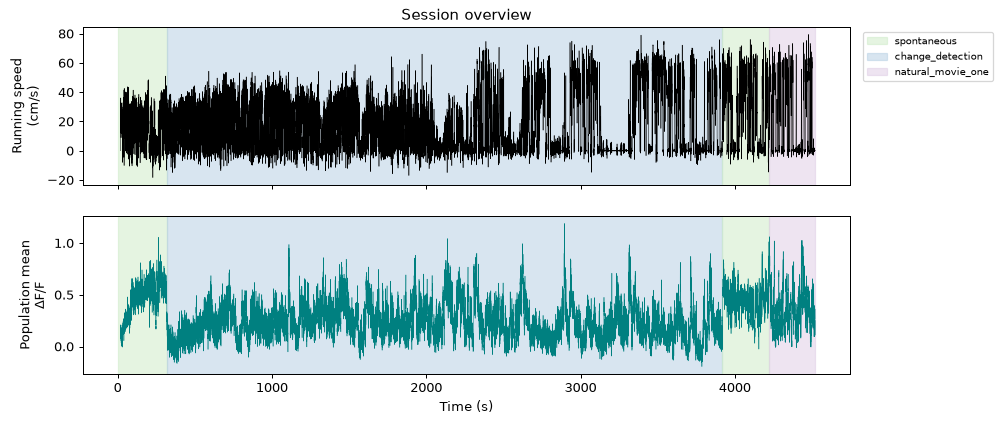

In [18]:
# Build the panels from whatever behavior streams this dataset actually has.
# EDIT: add or remove entries to match your dataset.
panels = [(timestamps, population, 'Population mean\n' + r'$\Delta$F/F', 'teal')]

if 'running_speed' in dir():
    panels.insert(0, (running_ts, running_speed, 'Running speed\n(cm/s)', 'k'))

fig, axes = plt.subplots(len(panels), 1, figsize=(11, 2.5 * len(panels)),
                         sharex=True, squeeze=False)
axes = axes[:, 0]

for ax, (x, y, ylabel, color) in zip(axes, panels):
    x_plot, y_plot = break_gaps(x, y)      # do not interpolate across missing data
    ax.plot(x_plot, y_plot, color=color, lw=0.4)
    ax.set_ylabel(ylabel)
    shade_epochs(ax)

axes[0].set_title('Session overview')
axes[-1].set_xlabel('Time (s)')

handles, labels = axes[0].get_legend_handles_labels()
unique = dict(zip(labels, handles))
axes[0].legend(unique.values(), unique.keys(), bbox_to_anchor=(1.01, 1.0),
               loc='upper left', fontsize=8)
plt.show()

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Now test the claim you wrote above &mdash; do not eyeball it.

Turn your sentence into a number you can check. If it compares epochs, compute the mean in each one,
alongside how long each epoch lasted, when in the session it happened, and what the animal was doing.
If it compares something else, compute the equivalent.

Before you look: **what would make this comparison unfair?** Write your answer down first, then see
whether the table bears it out.

Then go back and mark your claim as supported, contradicted, or untestable with this data. All three
are legitimate outcomes and all three belong in your README.

</div>

In [19]:
# Add the two things that could confound the comparison: when the epoch
# happened, and what the animal was doing during it.
rows = []
for label, row in epochs.iterrows():
    in_epoch = (timestamps >= row.start_time) & (timestamps < row.stop_time)
    in_epoch_run = (running_ts >= row.start_time) & (running_ts < row.stop_time)
    if in_epoch.sum() < 10:
        continue
    rows.append({'epoch': label,
                 'duration_s': round(float(row.stop_time - row.start_time), 1),
                 'n_samples': int(in_epoch.sum()),
                 'mid_session_min': round(float(row.start_time + row.stop_time) / 120, 1),
                 'mean_running': round(float(running_speed[in_epoch_run].mean()), 2),
                 'mean_activity': round(float(population[in_epoch].mean()), 4)})

pd.DataFrame(rows)

,epoch,duration_s,n_samples,mid_session_min,mean_running,mean_activity
0,spontaneous,317.7,3224,2.6,17.66,0.4710
1,change_detection,3601.8,38692,35.3,19.05,0.2281
2,spontaneous,300.3,3225,67.8,26.46,0.4401
3,natural_movie_one,300.2,3225,72.8,21.93,0.3677


<div style="border-left: 3px solid #7B9E3F; padding: 1px; padding-left: 10px; background: #FBFDF7; ">

<b>SOLUTION.</b> <i>Worked here on one example dataset. Your dataset will give different numbers &mdash; the reasoning is what transfers.</i>

Read `duration_s` and `n_samples` before you read `mean_activity`.

**Unshaded stretches are not nothing.** Our example session happens to have gaps; many do not, and
finding a continuous trace is the ordinary result. Here, the intervals with no epoch defined are
breaks between acquisition blocks. Neural recording often continues
through them while behavioral streams stop, so the same interval can be simultaneously present in one
signal and missing from another. Do not assume an unshaded region is comparable to a shaded one.

**Check the direction of the claim first.** For the example claim written above it does not hold:
activity during the change-detection block is *lower* than during the gray-screen periods, the
opposite of what the claim asserts. Run this on a different session from the same mouse and the
direction can flip again. The figure itself does not settle it &mdash; the traces are too dense to
read a mean off by eye.

That is the point, and it is why you wrote the claim down before computing anything. The figure is
not wrong. The sentence you attached to it was a guess, and a plausible sentence beside a real figure
is easy to believe.

Even once you have the direction right, the comparison is confounded, and the extra columns show how.
Read them down the table together:

- `mean_activity` &mdash; the quantity the claim is about.
- `mid_session_min` &mdash; epochs run in a fixed order, so epoch is perfectly confounded with time.
- `mean_running` &mdash; and with what the animal was doing.

If activity and one of those other columns move together across epochs, you cannot tell which one is
responsible. Indicators bleach and animals disengage over an hour, and running drives visual cortex
strongly on its own. Whether these line up helpfully or not is luck, and it differs between sessions.

Note the durations too: the task block runs an order of magnitude longer than the others, so the means
are not equally precise estimates.

No statistical test fixes any of this &mdash; these are properties of the experimental design, which
is why you check them before running the analysis. The honest comparison uses equal-duration windows
matched for time in session and running state. Write in your README what you would need to test the
claim properly, and if the session cannot support it, say so.

</div>

---

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h1>Part 3: Align activity to event onsets</h1>

The session overview shows everything at once, which means it shows very little. To see a response
you need to **align** activity to the times when something happened, and look across repeats.

"Something happened" need not be a visual stimulus. It might be a sound, an optogenetic pulse, a
reward, a lick, or the start of a trial. Anything with a repeatable onset time works the same way
&mdash; and the rest of this notebook says "event" rather than "stimulus" for that reason.

This morning's tutorial averaged across presentations. Here we look at what the average hides.

</div>

In [20]:
# How many times was each condition presented?
events[CONDITION_COLUMN].value_counts()

,count
image_name,
im069,759
im065,718
im085,560
im061,544
im066,529
im063,522
im077,511
im062,469
omitted,186


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Are all of these events the same kind of event?</h3>

An event table usually contains rows that are **not equivalent trials**. Depending on the dataset
that might be first versus repeated presentations, rewarded versus unrewarded trials, different
stimulus families, trials the animal responded to versus ignored, blocks recorded before and after
a manipulation, or blank and omitted entries that are not events at all.

This matters before you align anything, for two reasons:

- **Response magnitude can differ several-fold between trial types.** Averaging them together dilutes
  the response toward whichever type is most numerous &mdash; which is often the weakest one.
- **Trial types differ in what else is happening.** Reward, licking, and arousal ride along with some
  trial types and not others, so a difference you attribute to the stimulus may not be about the
  stimulus.

Find the columns in your table that distinguish trial types, and count them.

</div>

In [21]:
# EDIT: which columns in your table distinguish kinds of trials?
for column in ['is_change', 'omitted', 'rewarded', 'hit', 'stim_name', 'stimulus_family']:
    if column in events.columns:
        print(f'{column}:')
        print(events[column].value_counts().to_string())
        print()

is_change:
is_change
False    4590
True      208

omitted:
omitted
False    4612
True      186



<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

To compare them we need to cut a window of data around each onset. Same
`align_to_events` helper as this morning's tutorial.

</div>

In [22]:
def align_to_events(data, timestamps, event_times, pre=0.5, post=1.5):
    """Cut a window of data around each event time.

    Returns (windows, t) where t is time in seconds relative to the event.
    """
    dt = np.median(np.diff(timestamps))
    n_pre, n_post = int(pre / dt), int(post / dt)

    windows = []
    for event_time in event_times:
        i = np.searchsorted(timestamps, event_time)

        # skip events too close to the start or end of the recording
        if i - n_pre >= 0 and i + n_post <= len(timestamps):
            windows.append(data[i - n_pre:i + n_post])

    t = np.arange(-n_pre, n_post) * dt
    return np.array(windows), t

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Pick two trial types from your table and align the population average to
each separately, then plot both on the same axes.

Write down your prediction first: do you expect a difference, and how large?

Then choose which type to carry forward, and one condition within it. Name three things, because the
rest of Part 3 refers to them:

| name | what it holds |
| --- | --- |
| `onsets_pool` | onset times of ALL trials of your chosen type |
| `onsets` | onset times of the one condition you picked |
| `ROI` | index of your example cell |

</div>

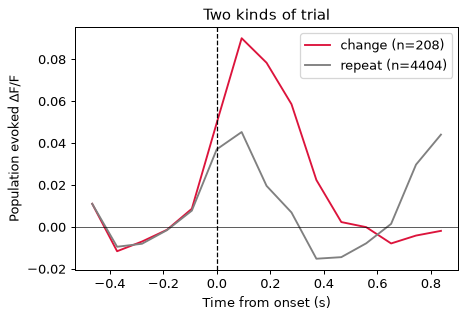

In [23]:
population = activity.mean(axis=1)

# EDIT: define two groups of onsets to compare in your dataset.
# Here: image changes vs. repeated presentations of the same images.
group_a = events.loc[events.is_change == 1, ONSET_COLUMN].values
group_b = events.loc[(events.is_change != 1) & (events.omitted != 1), ONSET_COLUMN].values

plt.figure(figsize=(5.5, 3.5))
for onsets_type, label, color in [(group_a, 'change', 'crimson'),
                                  (group_b, 'repeat', 'gray')]:
    windows_type, t_type = align_to_events(population, timestamps, onsets_type,
                                           pre=0.5, post=1.0)
    baseline = windows_type[:, t_type < 0].mean(axis=1, keepdims=True)
    evoked = (windows_type - baseline).mean(axis=0)
    plt.plot(t_type, evoked, color=color, label=f'{label} (n={len(windows_type)})')

plt.axvline(0, color='k', ls='--', lw=1)
plt.axhline(0, color='k', lw=0.5)
plt.xlabel('Time from onset (s)')
plt.ylabel("Population evoked " + r"$\Delta$F/F")
plt.legend()
plt.title('Two kinds of trial')
plt.show()

<div style="border-left: 3px solid #7B9E3F; padding: 1px; padding-left: 10px; background: #FBFDF7; ">

<b>SOLUTION.</b> <i>Worked here on one example dataset. Your dataset will give different numbers &mdash; the reasoning is what transfers.</i>

In our example the two trial types differ by roughly **four-fold**: one evokes a clear
population response peaking about 0.2&nbsp;s after onset, the other barely rises above baseline. Both
show the same images for the same duration.

The size of that gap is the useful number. It tells you that pooling these trials would have diluted
the response by most of its magnitude, and it sets your expectation for everything downstream: an
analysis run on the weaker type needs many more trials to see the same effect.

It also tells you which comparison you can actually interpret. If the two types differ in reward,
licking, or arousal as well as in stimulus history, then a difference between them is not
attributable to the stimulus alone.

**Whenever a trial-aligned average comes out flat, check this before anything else.** Align to the
trial type that should be most strongly driven and confirm you can see a response there. A flat
average from a poorly chosen trial type looks identical to a flat average from a timing error, and
this check distinguishes them in one plot.

</div>

In [24]:
# EDIT: work with the more strongly driven trial type from here on
onsets_pool = group_a
trial_type_mask = events.is_change == 1        # EDIT: matches group_a above

condition = events.loc[trial_type_mask, CONDITION_COLUMN].value_counts().index[0]
onsets = events.loc[trial_type_mask & (events[CONDITION_COLUMN] == condition),
                    ONSET_COLUMN].values

print(f'condition: {condition} | presentations of this type: {len(onsets)}')

condition: im069 | presentations of this type: 27


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Which cell to look at?</h3>

Showing "ROI 0" is an arbitrary choice you did not disclose. Ranking cells by how much they respond
is a *different* undisclosed choice unless you say so. Pick deliberately and write it down.

</div>

In [25]:
pre, post = 0.5, 1.0

# Rank cells on ALL trials of this type, not just one condition.
# NOTE: this re-selects ROI against the CURRENT `activity` matrix. If you
# subset or reorder cells at any point, indices from earlier cells no longer
# refer to the same neurons -- always re-derive them rather than carrying
# an index across a reshape.
after = np.array([activity[(timestamps >= t0) & (timestamps < t0 + 0.5)].mean(axis=0)
                  for t0 in onsets_pool])
before = np.array([activity[(timestamps >= t0 - 0.25) & (timestamps < t0)].mean(axis=0)
                   for t0 in onsets_pool])

# Use nanmean/nanstd: a single trial with an incomplete window (one that runs
# off the start or end of the recording) would otherwise turn EVERY cell's
# score into NaN, and you would conclude no cell responds.
difference = after - before
with np.errstate(invalid='ignore'):
    modulation = np.nanmean(difference, axis=0) / np.nanstd(difference, axis=0)

n_dropped = int(np.isnan(modulation).sum())
if n_dropped:
    print(f'{n_dropped} cells have no usable data and were skipped')
ROI = int(np.nanargmax(modulation))

print(f'most stimulus-modulated cell: ROI {ROI} (score {modulation[ROI]:.3f})')
print(f'median across cells: {np.nanmedian(modulation):.3f}')

most stimulus-modulated cell: ROI 5 (score 1.247)
median across cells: 0.288


In [26]:
windows, t = align_to_events(activity[:, ROI], timestamps, onsets, pre=pre, post=post)

print('windows shape (n_presentations, n_frames):', windows.shape)

windows shape (n_presentations, n_frames): (27, 15)


<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Compare the number of windows you got back against the number of onsets you
asked for. Are they the same?

If not, read the helper again and work out where the missing trials went &mdash; then decide whether
losing them matters for your analysis.

This is worth doing every time you call something that returns one row per trial. A function that
quietly returns fewer rows than you gave it will not raise an error; it will just make your
n smaller than you think it is.

</div>

In [27]:
print('onsets:           ', len(onsets))
print('windows returned: ', windows.shape[0])
print('trials dropped:   ', len(onsets) - windows.shape[0])

onsets:            27
windows returned:  27
trials dropped:    0


<div style="border-left: 3px solid #7B9E3F; padding: 1px; padding-left: 10px; background: #FBFDF7; ">

<b>SOLUTION.</b> <i>Worked here on one example dataset. Your dataset will give different numbers &mdash; the reasoning is what transfers.</i>

`align_to_events` skips any event whose window would run off the start or end of the
recording &mdash; sensible, since those windows would be the wrong length. But it does it
**silently**.

If you never compare the two numbers, every trial count you report downstream is quietly wrong. This
is a small instance of a large category: helper functions make reasonable decisions for you, and
those become invisible assumptions. **Check the shape of what comes back against what you expected.**

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Raster and PSTH</h3>

The raster shows every trial; the PSTH is their average. Plot them together so you can see what the
average discards.

</div>

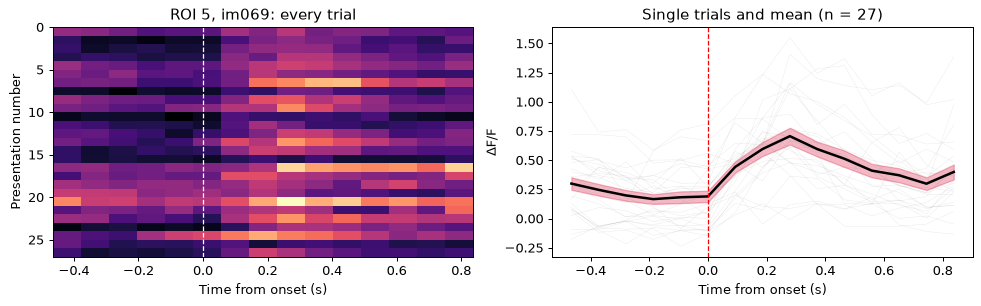

In [28]:
mean = windows.mean(axis=0)
sem = windows.std(axis=0) / np.sqrt(len(windows))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

axes[0].imshow(windows, aspect='auto', cmap='magma',
               extent=[t[0], t[-1], windows.shape[0], 0])
axes[0].axvline(0, color='white', ls='--', lw=1)
axes[0].set_xlabel('Time from onset (s)')
axes[0].set_ylabel('Presentation number')
axes[0].set_title(f'ROI {ROI}, {condition}: every trial')

axes[1].plot(t, windows.T, color='gray', lw=0.3, alpha=0.2)
axes[1].plot(t, mean, 'k', lw=2)
axes[1].fill_between(t, mean - sem, mean + sem, color='crimson', alpha=0.3)
axes[1].axvline(0, color='red', ls='--', lw=1)
axes[1].set_xlabel('Time from onset (s)')
axes[1].set_ylabel(r'$\Delta$F/F')
axes[1].set_title(f'Single trials and mean (n = {len(windows)})')

plt.tight_layout()
plt.show()

<div style="border-left: 3px solid #7B9E3F; padding: 1px; padding-left: 10px; background: #FBFDF7; ">

<b>SOLUTION.</b> <i>Worked here on one example dataset. Your dataset will give different numbers &mdash; the reasoning is what transfers.</i>

Almost no individual trial looks like the average. Even for the most modulated cell in the
session, the mean shows a modest bump while single trials are all over the place and many show
nothing at all.

This is normal cortical data, not a quality problem. But it sets up the rest of the notebook: **the
average is a small signal pulled out of large variability.** How much you can trust it depends
entirely on how many trials went into it.

</div>

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Now do it for every cell and plot the result as a heatmap, sorted by
response magnitude. How many cells respond at all?

</div>

In [29]:
responses = []
for roi in range(activity.shape[1]):
    windows_roi, t = align_to_events(activity[:, roi], timestamps, onsets, pre=pre, post=post)
    responses.append(windows_roi.mean(axis=0))

responses = np.array(responses)
print('responses shape (n_cells, n_timepoints):', responses.shape)

responses shape (n_cells, n_timepoints): (51, 15)


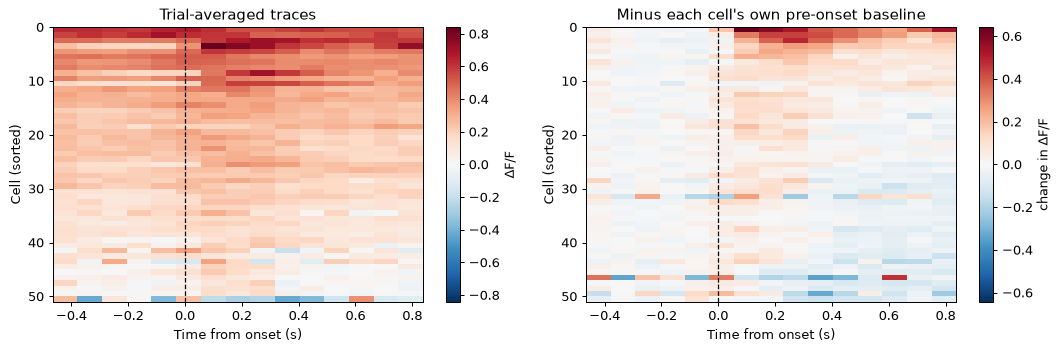

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# LEFT: raw trial-averaged traces, sorted by their mean
order_raw = np.argsort(responses.mean(axis=1))[::-1]
lim = np.abs(responses).max()
im0 = axes[0].imshow(responses[order_raw], aspect='auto', cmap='RdBu_r', vmin=-lim, vmax=lim,
                     extent=[t[0], t[-1], len(responses), 0])
axes[0].set_title('Trial-averaged traces')
plt.colorbar(im0, ax=axes[0], label=r'$\Delta$F/F')

# RIGHT: same thing, minus each cell's own pre-onset baseline
baseline = responses[:, t < 0].mean(axis=1, keepdims=True)
change = responses - baseline

order = np.argsort(change[:, t >= 0].mean(axis=1))[::-1]
lim = np.abs(change).max()
im1 = axes[1].imshow(change[order], aspect='auto', cmap='RdBu_r', vmin=-lim, vmax=lim,
                     extent=[t[0], t[-1], len(change), 0])
axes[1].set_title("Minus each cell's own pre-onset baseline")
plt.colorbar(im1, ax=axes[1], label=r'change in $\Delta$F/F')

for ax in axes:
    ax.axvline(0, color='k', ls='--', lw=1)
    ax.set_xlabel('Time from onset (s)')
    ax.set_ylabel('Cell (sorted)')

plt.tight_layout()
plt.show()

<div style="border-left: 3px solid #7B9E3F; padding: 1px; padding-left: 10px; background: #FBFDF7; ">

<b>SOLUTION.</b> <i>Worked here on one example dataset. Your dataset will give different numbers &mdash; the reasoning is what transfers.</i>

These two panels are the same data and tell different stories &mdash; that is the lesson.

The left panel looks like a clean ranking of responsive cells, but it is mostly showing **which cells
sit at a higher dF/F level**, not which cells respond. Each row is nearly flat in time; the vertical
gradient is baseline, not stimulus. Sorting by the row mean sorts by baseline.

The right panel subtracts each cell's own pre-onset baseline, so what is left is the *change* the
stimulus produced. Now a minority of cells respond, most barely at all, and a few are suppressed
&mdash; and the structure runs left-to-right (before vs after onset) rather than top-to-bottom.

One transformation, entirely different interpretation. Neither panel is wrong; the first just does not
answer the question we asked of it. **This is why you plot after each step.**

Two kinds of variability are now on the table, and the distinction drives Part 4:

- **Across trials** (the raster): one neuron, one stimulus, a different response each time.
- **Across neurons** (the right panel): different neurons doing genuinely different things.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>The same analysis on a different signal</h3>

Many datasets give you more than one version of "neural activity". Calcium imaging pipelines often
provide both a **continuous** signal (dF/F) and a **sparse, deconvolved** one (often called events
or spikes) &mdash; an estimate of when activity actually occurred, with the slow decay of the
indicator removed. Some provide only one.

**Check what your dataset has before assuming.** List the interfaces in the processing container. If
there is only one representation, say so in your README and skip this comparison &mdash; that is a
property of the dataset worth recording, not a step you failed.

Where both exist they are not interchangeable, and which you use changes your numbers.

</div>

In [31]:
# EDIT: the second activity representation in your dataset, if it has one
events_trace = nwb.processing[plane]['event_timeseries']

activity_events = events_trace.data[:]
activity_events = np.where(np.abs(activity_events) < 1e-12, 0.0, activity_events)

print('dff:    ', activity.shape, '| fraction exactly zero: %.3f' % (activity == 0).mean())
print('events: ', activity_events.shape,
      '| fraction exactly zero: %.3f' % (activity_events == 0).mean())
print('timestamps shared:', activity_events.shape[0] == len(timestamps))

dff:     (48366, 51) | fraction exactly zero: 0.000
events:  (48366, 51) | fraction exactly zero: 0.880
timestamps shared: True


<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** If your dataset has two activity representations, align both to the same
onsets and plot the trial-averaged population response side by side. What differs &mdash; the
duration, the shape, the size relative to baseline?

If it has only one, note that in your README and move on.

</div>

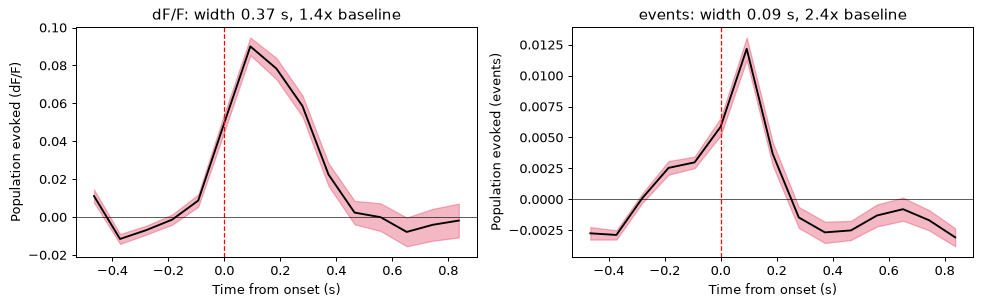

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

for ax, A, label in [(axes[0], activity, r'dF/F'),
                     (axes[1], activity_events, 'events')]:
    windows_pop, t_pop = align_to_events(A.mean(axis=1), timestamps, onsets_pool,
                                         pre=0.5, post=1.0)
    baseline = windows_pop[:, t_pop < 0].mean(axis=1, keepdims=True)
    evoked = (windows_pop - baseline)

    mean = evoked.mean(axis=0)
    sem = evoked.std(axis=0) / np.sqrt(len(evoked))

    # width at half maximum, and how far above baseline the peak sits
    above_half = mean > mean.max() / 2
    width = above_half.sum() * np.median(np.diff(t_pop))
    raw = windows_pop.mean(axis=0)
    contrast = raw.max() / raw[t_pop < 0].mean()

    ax.plot(t_pop, mean, 'k')
    ax.fill_between(t_pop, mean - sem, mean + sem, color='crimson', alpha=0.3)
    ax.axvline(0, color='red', ls='--', lw=1)
    ax.axhline(0, color='k', lw=0.5)
    ax.set_xlabel('Time from onset (s)')
    ax.set_ylabel(f'Population evoked ({label})')
    ax.set_title(f'{label}: width {width:.2f} s, {contrast:.1f}x baseline')

plt.tight_layout()
plt.show()

<div style="border-left: 3px solid #7B9E3F; padding: 1px; padding-left: 10px; background: #FBFDF7; ">

<b>SOLUTION.</b> <i>Worked here on one example dataset. Your dataset will give different numbers &mdash; the reasoning is what transfers.</i>

Three differences worth naming.

**Duration.** The events response is narrower &mdash; in our session roughly a single frame at half
maximum against three or four for dF/F, and its mass sits earlier. dF/F inherits the indicator's rise
and decay, which smears activity forward in time; deconvolution is an attempt to undo that. If you
care about response duration, or about ordering responses across areas or cells, this is not a
detail.

**Contrast.** Relative to its own pre-onset baseline the events signal rises proportionally more
(roughly 2&times; versus 1.4&times; here), because deconvolution removes the slowly varying
fluorescence dF/F carries between transients.

**Sparsity.** The events trace is around 90% exact zeros. That is the point of it &mdash; but it means
single-trial, single-cell estimates are mostly zero, so anything computed per trial is far noisier
even though the population average looks cleaner. We will see that cost in Part 4.

<b>A caution about reading latency off either panel.</b> At roughly 10&nbsp;Hz one frame is about
100&nbsp;ms, so "peaks one frame earlier" is at the limit of what this sampling rate can resolve, and
which frame wins can change between sessions. Whenever you quote a latency, check it against your
frame interval first &mdash; a difference smaller than one sample is not a measurement. Duration and
contrast, measured across several frames, are the more robust comparisons here.

Neither signal is more correct. dF/F is a smoothed, always-present measure; events are a sparse
estimate of a latent variable and inherit whatever assumptions the deconvolution made. **Report which
one you used**, because a reader cannot tell from the figure and your numbers depend on it.

</div>

---

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h1>Part 4: Signal and noise correlations</h1>

<h3>First, the math</h3>

The Pearson correlation between two variables $x$ and $y$ is

$$ r = \frac{\sum_i (x_i - \bar{x})(y_i - \bar{y})}
              {\sqrt{\sum_i (x_i - \bar{x})^2}\;\sqrt{\sum_i (y_i - \bar{y})^2}} $$

In words:

1. **Center** each variable by subtracting its mean.
2. **Multiply** the centered values pointwise and sum &mdash; large and positive when they vary
   together, negative when oppositely, near zero when unrelated.
3. **Normalize** by each variable's spread, forcing the result between -1 and +1.

Compute it once by hand before running it thousands of times.

</div>

In [33]:
# two cells' full traces
x = activity[:, ROI]
y = activity[:, ROI + 1]

# Step 1: center
x_centered = x - x.mean()
y_centered = y - y.mean()

# Step 2: multiply and sum
numerator = np.sum(x_centered * y_centered)

# Step 3: normalize by the spread of each
denominator = np.sqrt(np.sum(x_centered ** 2)) * np.sqrt(np.sum(y_centered ** 2))

print('n observations:  ', len(x))
print('r by hand:       ', round(numerator / denominator, 6))
print('r from np.corrcoef:', round(np.corrcoef(x, y)[0, 1], 6))

n observations:   48366
r by hand:        0.182387
r from np.corrcoef: 0.182387


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

Two consequences that matter for everything below:

- $r$ says nothing about response **size**, only whether two things move together.
- $r$ is computed over a set of paired observations, and **how many observations you have determines
  how noisy $r$ is** &mdash; but the value itself gives you no clue how many there were.

</div>

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** What does a given value of $r$ look like? Simulate pairs with known
correlations and plot them.

</div>

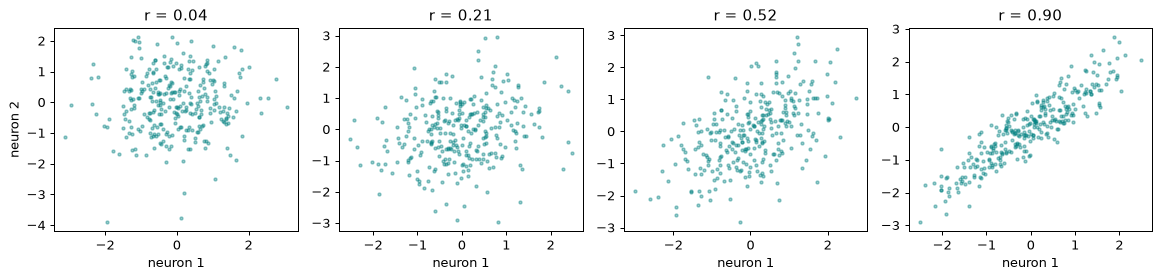

In [34]:
rng = np.random.default_rng(0)
n = 300

fig, axes = plt.subplots(1, 4, figsize=(13, 3.2))

for ax, target_r in zip(axes, [0.0, 0.2, 0.5, 0.9]):
    a = rng.normal(size=n)
    b = target_r * a + np.sqrt(1 - target_r ** 2) * rng.normal(size=n)
    ax.scatter(a, b, s=6, alpha=0.4, color='teal')
    ax.set_title(f'r = {np.corrcoef(a, b)[0, 1]:.2f}')
    ax.set_xlabel('neuron 1')

axes[0].set_ylabel('neuron 2')
plt.tight_layout()
plt.show()

<div style="border-left: 3px solid #7B9E3F; padding: 1px; padding-left: 10px; background: #FBFDF7; ">

<b>SOLUTION.</b> <i>Worked here on one example dataset. Your dataset will give different numbers &mdash; the reasoning is what transfers.</i>

An $r$ of 0.2 looks like a formless blob; 0.5 is a cloud you would not confidently call a
relationship by eye.

Remember these pictures. Mean pairwise correlations in cortex are typically 0.01&ndash;0.1 &mdash;
weaker than the leftmost panel. Real and consequential at the population level, but no single pair
looks impressive.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Two reasons neurons are correlated</h3>

- **Signal correlation.** Do they respond similarly *across conditions*? Correlate the two neurons'
  tuning curves &mdash; their average response to each condition.
- **Noise correlation.** When the *same* condition repeats, do they fluctuate together around their
  own averages? Subtract each condition's mean and correlate the residuals.

A "condition" is whatever your event table repeats: an image, a grating direction, a tone, a
photostimulation target, a task context. All that matters is that it recurs enough times to average
over.

Same data, different thing averaged over:

| | what is correlated | one observation is |
| --- | --- | --- |
| signal | condition means | one condition |
| noise | within-condition residuals | one trial |

That last column matters more than anything else in this notebook.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Step 1: choose which events to use</h3>

Not every event is comparable to every other. Decide which subset is a fair comparison and write down
why.

</div>

In [35]:
# EDIT: restrict to comparable events for your dataset
subset = events.copy()

# In this change-detection task, "change" presentations are followed by licking and
# reward, and "omitted" presentations are not stimuli at all. Keep only the repeats.
if 'is_change' in subset.columns:
    subset = subset[subset['is_change'] != 1]
if 'omitted' in subset.columns:
    subset = subset[subset['omitted'] != 1]

onsets_all = subset[ONSET_COLUMN].values
labels = subset[CONDITION_COLUMN].values

print(f'{len(events)} events -> {len(subset)} after filtering')
print(pd.Series(labels).value_counts().to_string())

4798 events -> 4404 after filtering
im069    732
im065    693
im085    535
im061    518
im066    503
im063    496
im077    485
im062    442


<div style="border-left: 3px solid #7B9E3F; padding: 1px; padding-left: 10px; background: #FBFDF7; ">

<b>SOLUTION.</b> <i>Worked here on one example dataset. Your dataset will give different numbers &mdash; the reasoning is what transfers.</i>

Here we go the **other way** from Part 3, and it is worth being explicit about why.

Part 3 aligned to changes, because those are the strongly driven events and we wanted to see a
response. For correlations we use **repeats** instead. The trade-off:

| | changes | repeats |
| --- | --- | --- |
| trials | ~240 | ~4400 |
| trials per condition | ~30 | ~500 |
| stimulus drive | strong | weak (adapted) |
| confounds | licking, reward, arousal | relatively few |

Changes are strongly driven but few, and each one is followed by licking and reward &mdash; which
would put behavior-driven variability into what we are calling "noise". Repeats are weakly driven but
numerous and behaviorally quiet.

For **noise** correlations the trial count dominates, so repeats win. For **signal** correlations
neither choice rescues you: 8 conditions is 8 conditions either way, which is the whole point of the
reliability check below.

Neither answer is universally right, and running it both ways is a reasonable thing to do. What
matters is that you chose deliberately, know what the choice costs, and state it in your methods.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Step 2: one number per trial per neuron</h3>

We need a `(n_trials, n_cells)` matrix. Average each aligned window over a response window, and
subtract a **baseline** from just before onset &mdash; otherwise each trial's "response" includes
wherever the cell happened to be sitting beforehand, and those levels drift together across the
population from bleaching, arousal, and movement.

<b>Choosing the two windows is dataset-specific.</b> The response window should cover the response
your Part 3 plot showed &mdash; look at it rather than copying a number from here, since a calcium
signal and a spike rate need very different windows. The baseline window should sit in the gap
before onset, and must **exclude any stimulation artifact**: with optogenetics or electrical
stimulation the frames around the pulse can be unusable, so leave a margin on both sides.

</div>

In [36]:
RESPONSE_WINDOW = (0.0, 0.5)       # seconds after onset
BASELINE_WINDOW = (-0.25, 0.0)     # seconds before onset

R = []
for roi in range(activity.shape[1]):
    windows_roi, t_roi = align_to_events(activity[:, roi], timestamps, onsets_all,
                                         pre=-BASELINE_WINDOW[0], post=RESPONSE_WINDOW[1])
    response = windows_roi[:, t_roi >= 0].mean(axis=1)
    baseline = windows_roi[:, t_roi < 0].mean(axis=1)
    R.append(response - baseline)

R = np.array(R).T                  # (n_trials, n_cells)
labels_used = labels[:R.shape[0]]  # align_to_events may have dropped trials

print('R shape (n_trials, n_cells):', R.shape)
print('conditions:', len(np.unique(labels_used)))

R shape (n_trials, n_cells): (4404, 51)
conditions: 8


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Step 3: tuning curves &mdash; look before correlating</h3>

</div>

In [37]:
conditions = np.unique(labels_used)
tuning = np.vstack([R[labels_used == c].mean(axis=0) for c in conditions])

print('tuning shape (n_conditions, n_cells):', tuning.shape)

tuning shape (n_conditions, n_cells): (8, 51)


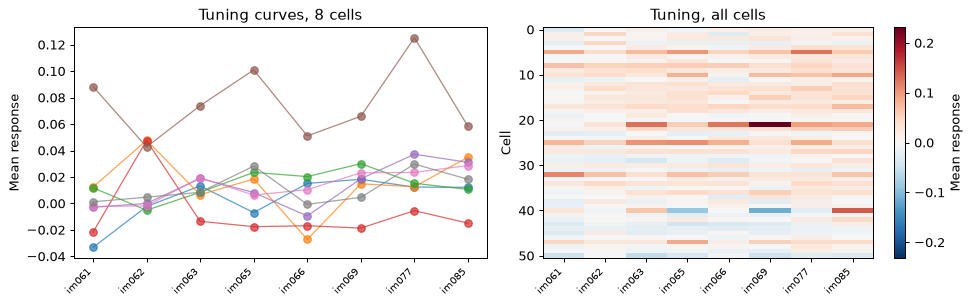

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

for roi in range(min(8, tuning.shape[1])):
    axes[0].plot(range(len(conditions)), tuning[:, roi], marker='o', lw=1, alpha=0.7)
axes[0].set_ylabel('Mean response')
axes[0].set_title('Tuning curves, 8 cells')

lim = np.abs(tuning).max()
im = axes[1].imshow(tuning.T, aspect='auto', cmap='RdBu_r', vmin=-lim, vmax=lim)
axes[1].set_ylabel('Cell')
axes[1].set_title('Tuning, all cells')
plt.colorbar(im, ax=axes[1], label='Mean response')

for ax in axes:
    ax.set_xticks(range(len(conditions)))
    ax.set_xticklabels(conditions, rotation=45, ha='right', fontsize=8)

plt.tight_layout()
plt.show()

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** How many numbers make up one neuron's tuning curve?

That is how many paired observations each signal correlation gets. Write it down.

</div>

In [39]:
print('numbers per tuning curve:', tuning.shape[0])
print('trials available for noise correlations:', R.shape[0])

numbers per tuning curve: 8
trials available for noise correlations: 4404


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Step 4: residuals &mdash; look before correlating</h3>

Subtract **each condition's own mean**, not the grand mean. Subtracting the grand mean would leave
the differences between conditions in the residuals, making your "noise" correlation partly a signal
correlation.

</div>

In [40]:
residuals = R.copy().astype(float)

for c in conditions:
    mask = labels_used == c
    residuals[mask] -= R[mask].mean(axis=0)      # each condition's OWN mean

print('residuals shape:', residuals.shape)
print('mean of residuals (should be ~0):', round(float(residuals.mean()), 10))

residuals shape: (4404, 51)
mean of residuals (should be ~0): -1e-10


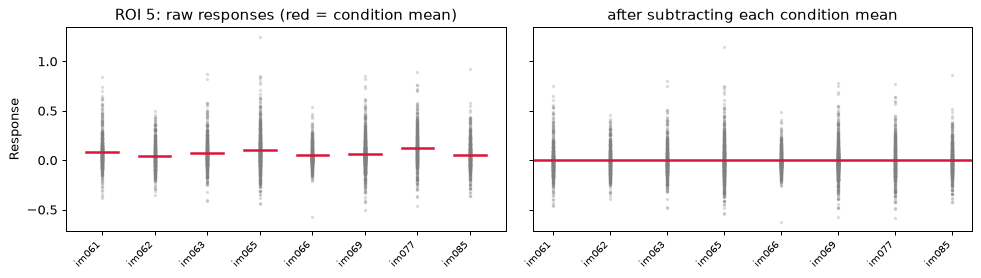

In [41]:
roi = ROI          # the stimulus-modulated cell from Part 3

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2), sharey=True)

for i, c in enumerate(conditions):
    axes[0].scatter(np.full((labels_used == c).sum(), i), R[labels_used == c, roi],
                    s=3, alpha=0.2, color='gray')
    axes[0].plot([i - 0.3, i + 0.3], [tuning[i, roi]] * 2, color='crimson', lw=2)
axes[0].set_title(f'ROI {roi}: raw responses (red = condition mean)')
axes[0].set_ylabel('Response')

for i, c in enumerate(conditions):
    axes[1].scatter(np.full((labels_used == c).sum(), i), residuals[labels_used == c, roi],
                    s=3, alpha=0.2, color='gray')
axes[1].axhline(0, color='crimson', lw=2)
axes[1].set_title('after subtracting each condition mean')

for ax in axes:
    ax.set_xticks(range(len(conditions)))
    ax.set_xticklabels(conditions, rotation=45, ha='right', fontsize=8)

plt.tight_layout()
plt.show()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Step 5: correlate</h3>

`np.corrcoef` correlates **rows**, so transpose to get cells rather than trials. Getting this
backwards produces a plausible matrix of entirely the wrong thing &mdash; check the output shape
against the number of cells.

</div>

In [42]:
C_signal = np.corrcoef(tuning.T)         # (n_conditions, n_cells) -> cells
C_noise = np.corrcoef(residuals.T)       # (n_trials, n_cells)     -> cells

pairs = np.triu_indices(C_signal.shape[0], k=1)   # each pair once, no diagonal
signal_values = C_signal[pairs]
noise_values = C_noise[pairs]

print('cells:', C_signal.shape[0], '-> unique pairs:', len(signal_values))
print(f'signal correlation: mean {np.nanmean(signal_values):+.4f}   '
      f'({tuning.shape[0]} observations per pair)')
print(f'noise  correlation: mean {np.nanmean(noise_values):+.4f}   '
      f'({residuals.shape[0]} observations per pair)')

cells: 51 -> unique pairs: 1275
signal correlation: mean +0.1507   (8 observations per pair)
noise  correlation: mean +0.0776   (4404 observations per pair)


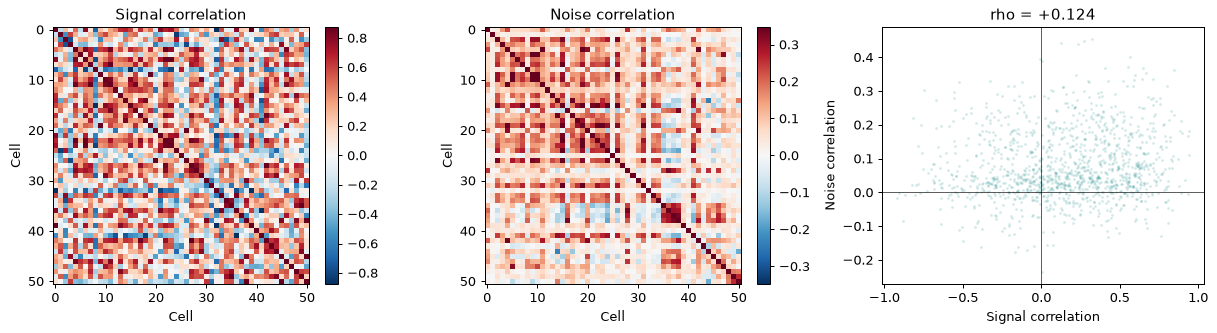

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))

for ax, C, label in [(axes[0], C_signal, 'Signal correlation'),
                     (axes[1], C_noise, 'Noise correlation')]:
    # scale each matrix to its own range so neither saturates
    off_diagonal = C[np.triu_indices(C.shape[0], k=1)]
    lim = np.nanpercentile(np.abs(off_diagonal), 99)
    im = ax.imshow(C, cmap='RdBu_r', vmin=-lim, vmax=lim)
    ax.set_xlabel('Cell')
    ax.set_ylabel('Cell')
    ax.set_title(label)
    plt.colorbar(im, ax=ax, fraction=0.046)

axes[2].scatter(signal_values, noise_values, s=2, alpha=0.1, color='teal')
axes[2].axhline(0, color='k', lw=0.5)
axes[2].axvline(0, color='k', lw=0.5)
axes[2].set_xlabel('Signal correlation')
axes[2].set_ylabel('Noise correlation')

rho, p_value = stats.spearmanr(signal_values, noise_values, nan_policy='omit')
axes[2].set_title(f'rho = {rho:+.3f}')

plt.tight_layout()
plt.show()

<div style="border-left: 3px solid #7B9E3F; padding: 1px; padding-left: 10px; background: #FBFDF7; ">

<b>SOLUTION.</b> <i>Worked here on one example dataset. Your dataset will give different numbers &mdash; the reasoning is what transfers.</i>

Signal and noise correlations are positively related &mdash; the classic result. Neurons that
like the same stimuli also share their trial-to-trial fluctuations, found in essentially every
cortical area. It matters for coding, because shared noise aligned with the signal does not average
away as you add neurons.

Now compare the two matrices' **texture**, not their numbers. One has visible structure; the other is
closer to salt-and-pepper across the full range. That is what badly estimated correlations look
like &mdash; and both came from the same function on the same data.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h1>Is this result trustworthy?</h1>

Every number so far is a point estimate with no error bar. The single most useful check: **would you
get the same answer with half the data?**

Split trials in half at random, compute the correlations on each half separately, and correlate the
two halves' answers. Split **within each condition** so both halves see every condition.

Three outcomes, and all three are informative:

- **One high, one low** &mdash; trust the high one, and say why the other is not trustworthy.
- **Both high** &mdash; you have enough data for both; proceed.
- **Both near zero** &mdash; report that. It usually means the condition variable you chose does not
  organise these neurons' responses, however well-balanced it looked in the inventory. That is a
  real result about your dataset, and it is a better README than a matrix you cannot defend.

</div>

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Before running it &mdash; which do you expect to be more reliable, signal or
noise correlations? Look back at the observation counts you wrote down.

</div>

In [44]:
def correlations_from(R_sub, labels_sub):
    """Signal and noise correlation matrices from a subset of trials."""
    conds = np.unique(labels_sub)
    tuning_sub = np.vstack([R_sub[labels_sub == c].mean(axis=0) for c in conds])

    resid_sub = R_sub.astype(float).copy()
    for c in conds:
        m = labels_sub == c
        resid_sub[m] -= R_sub[m].mean(axis=0)

    return np.corrcoef(tuning_sub.T), np.corrcoef(resid_sub.T)

In [45]:
rng = np.random.default_rng(0)
signal_reliability, noise_reliability = [], []

for _ in range(10):
    half_a, half_b = [], []
    for c in conditions:                       # split within each condition
        idx = rng.permutation(np.flatnonzero(labels_used == c))
        h = len(idx) // 2
        half_a.append(idx[:h])
        half_b.append(idx[h:2 * h])
    a, b = np.concatenate(half_a), np.concatenate(half_b)

    Cs_a, Cn_a = correlations_from(R[a], labels_used[a])
    Cs_b, Cn_b = correlations_from(R[b], labels_used[b])

    signal_reliability.append(stats.spearmanr(Cs_a[pairs], Cs_b[pairs],
                                             nan_policy='omit').statistic)
    noise_reliability.append(stats.spearmanr(Cn_a[pairs], Cn_b[pairs],
                                            nan_policy='omit').statistic)

print('split-half reliability (agreement between two independent halves)')
print(f'  signal: {np.mean(signal_reliability):.3f} +/- {np.std(signal_reliability):.3f}')
print(f'  noise:  {np.mean(noise_reliability):.3f} +/- {np.std(noise_reliability):.3f}')

split-half reliability (agreement between two independent halves)
  signal: 0.439 +/- 0.033
  noise:  0.923 +/- 0.004


<div style="border-left: 3px solid #7B9E3F; padding: 1px; padding-left: 10px; background: #FBFDF7; ">

<b>SOLUTION.</b> <i>Worked here on one example dataset. Your dataset will give different numbers &mdash; the reasoning is what transfers.</i>

**This is the most important result in the notebook.**

Noise correlations reproduce well across independent halves. Signal correlations reproduce much less
well &mdash; halve the data and you recover only part of the structure.

The reason is the observation counts from Step 3. Each noise correlation comes from thousands of
trials; each signal correlation comes from **one number per condition**, and correlating two short
vectors is noisy no matter how many trials went into each entry.

Look back at the heatmaps. They are equally smooth and equally colorful. **Nothing in that figure
tells you one is far more trustworthy than the other.** You only know because you split the data.

The general lesson: the reliability of a correlation is set by the number of *observations being
correlated*, not the number of trials you collected. Count them, and report split-half reliability
alongside any correlation matrix you publish.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Does the signal you chose change the answer?</h3>

Everything so far used one representation of activity. If your dataset provides a second one, repeat
the whole chain on it and compare the numbers that matter. If it provides only one, note that and
move on.

To repeat the chain you need the response-matrix construction as a reusable function rather than a
one-off block &mdash; so wrap it, the same way you wrapped the correlations.

</div>

In [46]:
def response_matrix(A):
    """Build the (n_trials, n_cells) baseline-subtracted response matrix for a signal."""
    rows = []
    for roi in range(A.shape[1]):
        w, t_w = align_to_events(A[:, roi], timestamps, onsets_all,
                                 pre=-BASELINE_WINDOW[0], post=RESPONSE_WINDOW[1])
        rows.append(w[:, t_w >= 0].mean(axis=1) - w[:, t_w < 0].mean(axis=1))
    return np.array(rows).T


def reliability(R_in, labels_in, n_iter=10, seed=0):
    """Split-half reliability of signal and noise correlations."""
    rng_local = np.random.default_rng(seed)
    iu = np.triu_indices(R_in.shape[1], k=1)
    out = {'signal': [], 'noise': []}
    for _ in range(n_iter):
        first, second = [], []
        for c in np.unique(labels_in):
            idx = rng_local.permutation(np.flatnonzero(labels_in == c))
            h = len(idx) // 2
            first.append(idx[:h])
            second.append(idx[h:2 * h])
        first, second = np.concatenate(first), np.concatenate(second)
        Cs1, Cn1 = correlations_from(R_in[first], labels_in[first])
        Cs2, Cn2 = correlations_from(R_in[second], labels_in[second])
        out['signal'].append(stats.spearmanr(Cs1[iu], Cs2[iu], nan_policy='omit').statistic)
        out['noise'].append(stats.spearmanr(Cn1[iu], Cn2[iu], nan_policy='omit').statistic)
    return np.mean(out['signal']), np.mean(out['noise'])

In [47]:
signals = [('dff', activity)]
if activity_events is not None:
    signals.append(('events', activity_events))

rows = []
for label, A in signals:
    R_sig = response_matrix(A)
    labels_sig = labels[:R_sig.shape[0]]
    Cs, Cn = correlations_from(R_sig, labels_sig)
    iu = np.triu_indices(R_sig.shape[1], k=1)
    rel_signal, rel_noise = reliability(R_sig, labels_sig)

    rows.append({'signal_type': label,
                 'frac_zero_trials': round(float((R_sig == 0).mean()), 3),
                 'signal_mean': round(float(np.nanmean(Cs[iu])), 4),
                 'noise_mean': round(float(np.nanmean(Cn[iu])), 4),
                 'signal_reliability': round(rel_signal, 3),
                 'noise_reliability': round(rel_noise, 3)})

pd.DataFrame(rows)

,signal_type,frac_zero_trials,signal_mean,noise_mean,signal_reliability,noise_reliability
0,dff,0.000,0.1507,0.0776,0.439,0.923
1,events,0.578,0.0377,0.0514,0.383,0.700


<div style="border-left: 3px solid #7B9E3F; padding: 1px; padding-left: 10px; background: #FBFDF7; ">

<b>SOLUTION.</b> <i>Worked here on one example dataset. Your dataset will give different numbers &mdash; the reasoning is what transfers.</i>

Every number moves, and one of them moves a lot.

Mean correlations are **smaller** on events, both signal and noise. Deconvolution removes the shared
slow fluorescence that inflates correlations between any two cells in the same field of view, so what
remains is closer to co-activation than to co-fluctuation of the baseline.

Noise-correlation **reliability drops substantially** on events &mdash; in our session from roughly
0.85 to 0.56. The `frac_zero_trials` column explains why: over half of the single-trial event
responses are exactly zero. A correlation computed from mostly-zero vectors rests on far less
information than the trial count suggests, even though the trial count is identical.

That is the reliability lesson again in a new disguise. **Counting trials is not the same as counting
information.** Two analyses with the same number of trials can differ two-fold in how reproducible
their answers are.

Signal-correlation reliability stays poor for both, for the reason it was always poor: 8 conditions is
8 conditions regardless of which signal you feed it.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<b>One column may not be the whole condition.</b>

A column can look like a clean condition variable &mdash; many levels, perfectly balanced &mdash;
while the stimulus varied in some <i>other</i> way at the same time. Two trials sharing that column's
value are then not repeats of the same thing, and averaging them together destroys the tuning you
were trying to measure.

Receptive-field mapping is the classic case: orientation is balanced, but the stimulus also moves
around the screen, so "144 repeats of 45&deg;" is really a handful of repeats at each of many
positions. The same trap appears whenever a design crosses two factors and you only notice one.

Check for it by asking what else varies across the trials you just called identical. Group by your
condition column, look at the other columns within a group, and see whether they are constant. If
they are not, either restrict to one level of the other factor, or make the condition the
<i>combination</i> of both.

</div>

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Signal correlations need a condition that repeats. Does your dataset have
one?

Inventory the candidate columns: how many distinct values, how many repeats, how balanced.

Then answer **two separate questions**, because they can disagree:

1. **Is the analysis possible?** Does some column have enough conditions with enough repeats?
2. **Is it meaningful?** Does that column label something you would expect neurons to be tuned
   *to*, in a way that a correlation across condition means would capture?

A column can pass the first test and fail the second. State a verdict on both, and check it against
your reliability numbers.

</div>

In [48]:
rows = []
for column in events.columns:
    values = events[column].dropna()
    if len(values) == 0:
        continue
    try:
        n_conditions = values.nunique()
    except TypeError:
        continue                        # unhashable column, e.g. arrays
    if not (2 <= n_conditions <= 60):
        continue
    counts = values.value_counts()
    rows.append({'column': column, 'n_conditions': int(n_conditions),
                 'min_reps': int(counts.min()), 'max_reps': int(counts.max()),
                 'balance': round(counts.min() / counts.max(), 2)})

pd.DataFrame(rows).sort_values('n_conditions', ascending=False)

,column,n_conditions,min_reps,max_reps,balance
0,HED,17,25,732,0.03
1,image_name,9,186,759,0.25
2,is_change,2,208,4590,0.05
3,omitted,2,186,4612,0.04


<div style="border-left: 3px solid #7B9E3F; padding: 1px; padding-left: 10px; background: #FBFDF7; ">

<b>SOLUTION.</b> <i>Worked here on one example dataset. Your dataset will give different numbers &mdash; the reasoning is what transfers.</i>

Our example passes: 8 images with hundreds of presentations each.

Note what this check does *not* do: it reports any column with the right shape, so an ID column with
20 values would pass and be nonsense. **The code tells you whether the analysis is possible; only you
can tell whether it is sensible.**

Some datasets have no repeated conditions at all &mdash; a brain&ndash;computer-interface experiment
with spontaneous periods, photostimulation, and neurofeedback trials has nothing that repeats like a
grating. The inventory comes back negative and **that is a result, not a failure.** Do not invent a
condition variable to force the analysis. Ask instead what that dataset is unusually good for: noise
correlations need no conditions at all, and if single neurons were photostimulated, measuring how
others respond is far stronger evidence of coupling than any correlation.

</div>

---

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h1>Summary</h1>

<h3>The process</h3>

1. **Find out what is in the file** before analyzing it &mdash; and check that the dataset supports
   your question. Sometimes the answer is no.
2. **Plot the data after each transformation.** Single trials before averages; tuning curves before
   correlations.
3. **Name every decision.** Event subset, condition column, response window, baseline. Each is a
   fork, and each belongs in your methods.
4. **Try to break your own result.** Split the data in half and see if the answer survives.
5. **Let the dataset answer back.** If the check says your result is noise, or the dataset has no
   variable that supports your question, that is the finding. Report it rather than reaching for the
   analysis you planned to run.

<h3>Traps this notebook demonstrated</h3>

| trap | how you catch it |
| --- | --- |
| A result from few observations looks like one from many | split-half reliability |
| A well-balanced condition variable that means nothing | reliability, not the inventory |
| A condition column that hides a second varying factor | group by it, check what else moves |
| Analyzing units that should have been dropped | select on quality columns, and say so |
| A helper function silently drops data | compare output shape to input |
| A column exists but carries no information | check that it actually varies |
| One bad trial turns every cell's score into NaN | count your NaNs; use `nanmean` |
| Epoch comparisons confounded with time and behavior | check durations, order, behavior |
| An example cell chosen to look good | state your selection rule |
| Data looks absent but is stored elsewhere | look in every container first |
| An index from an earlier cell after reshaping the data | re-derive indices, never carry them |

<h3>Why this matters</h3>

You can generate an analysis faster than you can validate one. The only defense is to know your data
well enough that a wrong answer looks wrong to **you** &mdash; because it will not look wrong to the
code, and it will not look wrong on the plot.

</div>